# Evidence for Histogram mismatch between different cases
### Clearly see that different MRI camera vendors have their different intensity distribution
This highlights the need to perform strong value scaling.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import animation
import random
import time
#PATH PROCESS
import os
import os.path
from pathlib import Path
import glob

import helpers

# the one library to handle nii images
import nibabel as nib

In [2]:
PROBLEM_TYPE = "CINE" 
IMAGE_TYPE = "4CH"
DATASET_FOLDER_PATH = os.path.abspath(f"..\\CMR-MULTI\\{PROBLEM_TYPE}_MULTI\\{IMAGE_TYPE}_TR\\image")

all_images = helpers.get_all_np_images(DATASET_FOLDER_PATH)

max value in all pixels for the image number 70 is 4181.0009765625
max value in all pixels for the image number 74 is 4541.78564453125
max value in all pixels for the image number 51 is 3491.964599609375


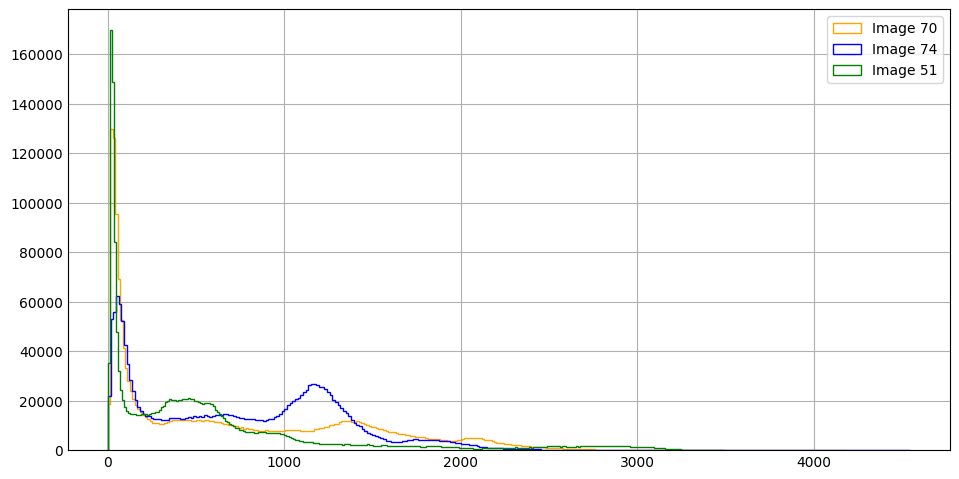

In [3]:
random_indices = np.random.randint(0, len(all_images), 3)
randomly_selected_images = [all_images[i] for i in random_indices]
colors = ['orange', 'blue', 'green']

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

### Trying out the min-max scaler

(217025575, 1)
max value in all pixels for the image number 34 is 1.0
max value in all pixels for the image number 31 is 1.0
max value in all pixels for the image number 91 is 1.0


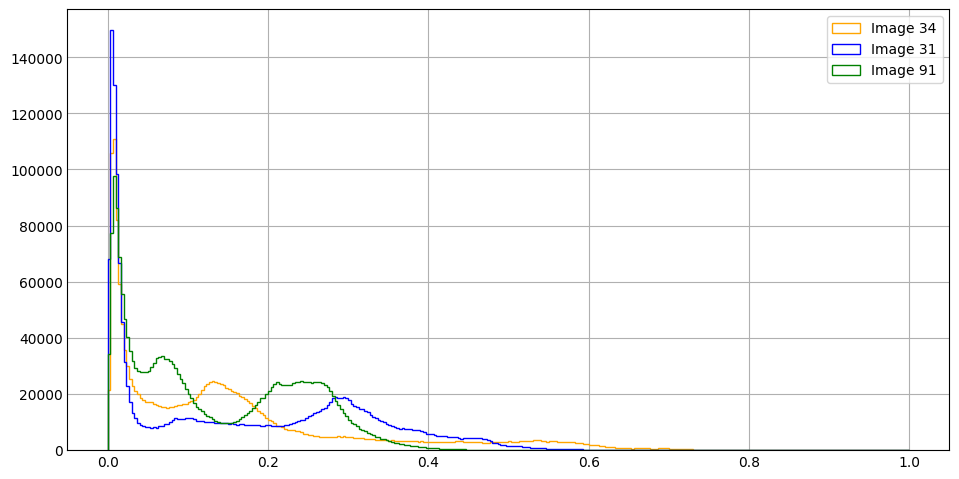

In [11]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

all_pixels = np.array(helpers.recursive_flatten(all_images)).reshape(-1, 1)
print(all_pixels.shape)
scaler = scaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = scaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

(217025575, 1)
max value in all pixels for the image number 34 is 5.190387335974422
max value in all pixels for the image number 31 is 5.536363964632877
max value in all pixels for the image number 91 is 8.107358584853554


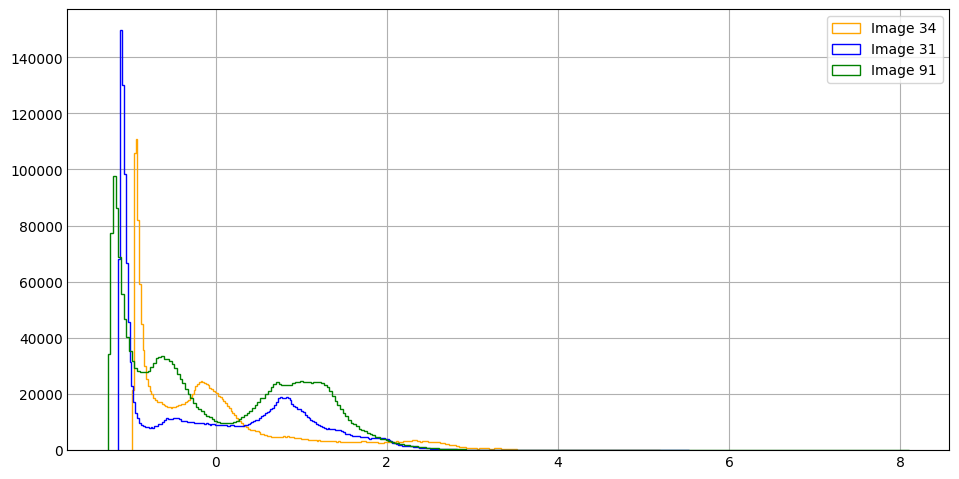

In [12]:
from sklearn.preprocessing import StandardScaler

zscaler = StandardScaler()

print(all_pixels.shape)
zscaler = zscaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = zscaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()
    

(217025575, 1)
max value in all pixels for the image number 34 is 4.899941718262933
max value in all pixels for the image number 31 is 3.062764009936576
max value in all pixels for the image number 91 is 4.607123364734529


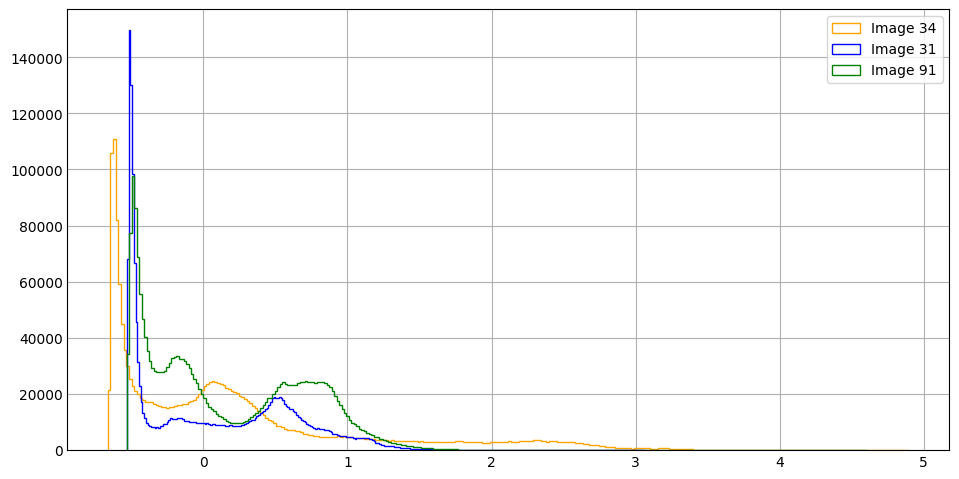

In [13]:
from sklearn.preprocessing import RobustScaler

rbscaler = RobustScaler()

print(all_pixels.shape)
rbscaler = rbscaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = rbscaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

### Looks like the StandardScaler (Z-score scaler) achieves a good histogrm matching between the 3 randomly selected cases
#### Now let's try to manually clip out the outlier data and rerun the Z-Scaler

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


def clip_outliers_from_img(image:np.ndarray):
    original_shape = image.shape
    p1, p99 = np.percentile(image.reshape(-1, 1), [1, 99])
    pixels = np.clip(image.reshape(-1, 1), p1, p99)
    clipped_img = pixels.reshape(original_shape)
    return clipped_img, pixels



all_pixels_after_clipping = np.array([]).reshape(-1, 1)
for img in tqdm(all_images):
    clipped_img, pixels = clip_outliers_from_img(img)
    all_pixels_after_clipping = np.concatenate((all_pixels_after_clipping, pixels))

print(f"finished clipping {len(all_images)} images")

#all_pixels_after_clipping = helpers.recursive_flatten(clipped_images)
all_pixels_after_clipping = np.array(all_pixels_after_clipping).reshape(-1, 1)

print(f"finished flattening {len(all_images)} images to {len(all_pixels_after_clipping)} pixels")

zscaler_clipped = StandardScaler()
zscaler_clipped = zscaler_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img, _ = clip_outliers_from_img(img) #Clip outliers
    img = zscaler_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

 54%|█████▍    | 57/105 [00:14<00:16,  2.87it/s]

finished training the scaler
max value in all pixels for the image number 34 is 1.0
max value in all pixels for the image number 31 is 1.0000000000000002
max value in all pixels for the image number 91 is 1.0000000000000002


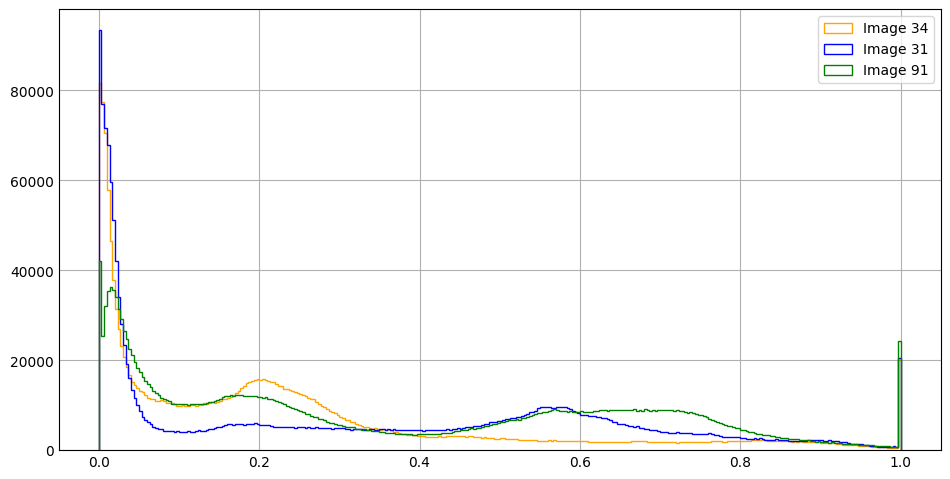

In [16]:
minmax_clipped = MinMaxScaler()
minmax_clipped = minmax_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img, _ = clip_outliers_from_img(img) #Clip outliers
    img = minmax_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

finished training the scaler
max value in all pixels for the image number 34 is 2.944122046659687
max value in all pixels for the image number 31 is 1.3044630176255356
max value in all pixels for the image number 91 is 1.3693926157433491


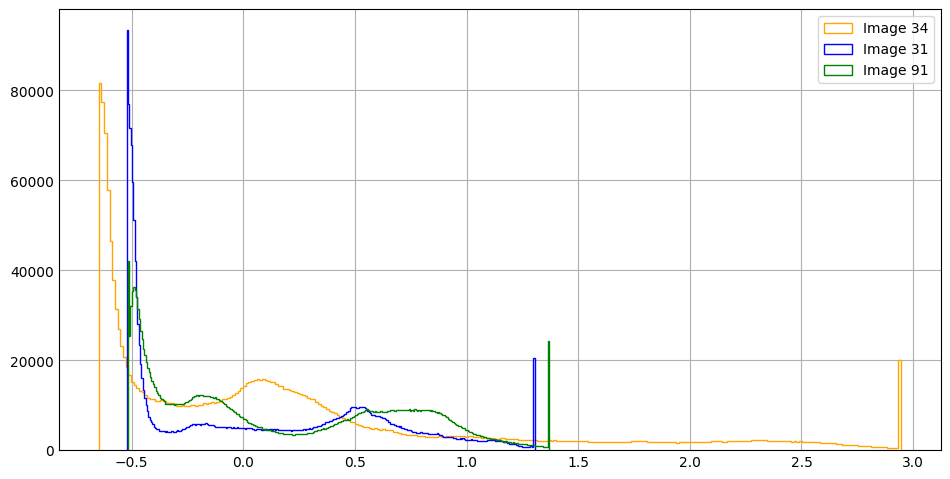

In [18]:
minmax_clipped = RobustScaler()
minmax_clipped = minmax_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img, _ = clip_outliers_from_img(img) #Clip outliers
    img = minmax_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

### Comparison between 3 samples only is not very accurate, Let's compare more histograms together to get a more accurate representation of the different distributions

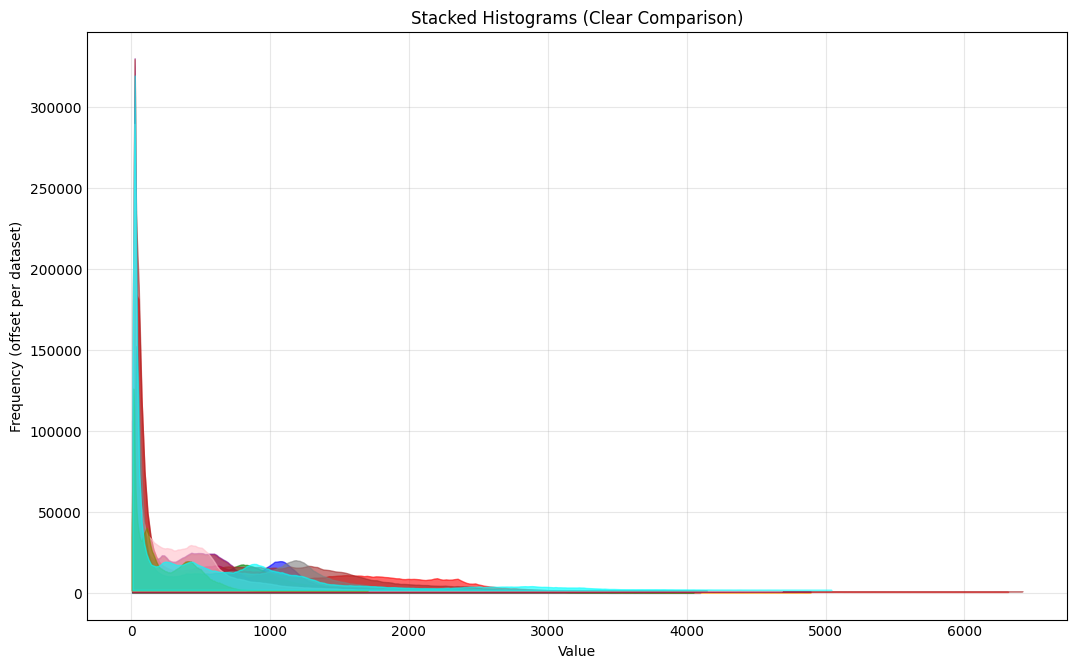

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

random_indices = np.random.randint(0, len(all_images), 10)
randomly_selected_images = [all_images[i] for i in random_indices]

colors = ['blue', 'orange', 'green', 'red', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

bins = 300
offset = 200  # controls vertical separation between histograms

plt.figure(figsize=(10, 6))

for i, img in enumerate(randomly_selected_images):
    data = helpers.recursive_flatten(img)
    hist, bin_edges = np.histogram(data, bins=bins)

    xs = (bin_edges[:-1] + bin_edges[1:]) / 2

    # shift each histogram upward
    plt.fill_between(xs, i * offset, hist + i * offset,
                 color=colors[i], alpha=0.6)

plt.xlabel("Value")
plt.ylabel("Frequency (offset per dataset)")
plt.title("Stacked Histograms (Clear Comparison)")
plt.grid(alpha=0.3)


plt.show()

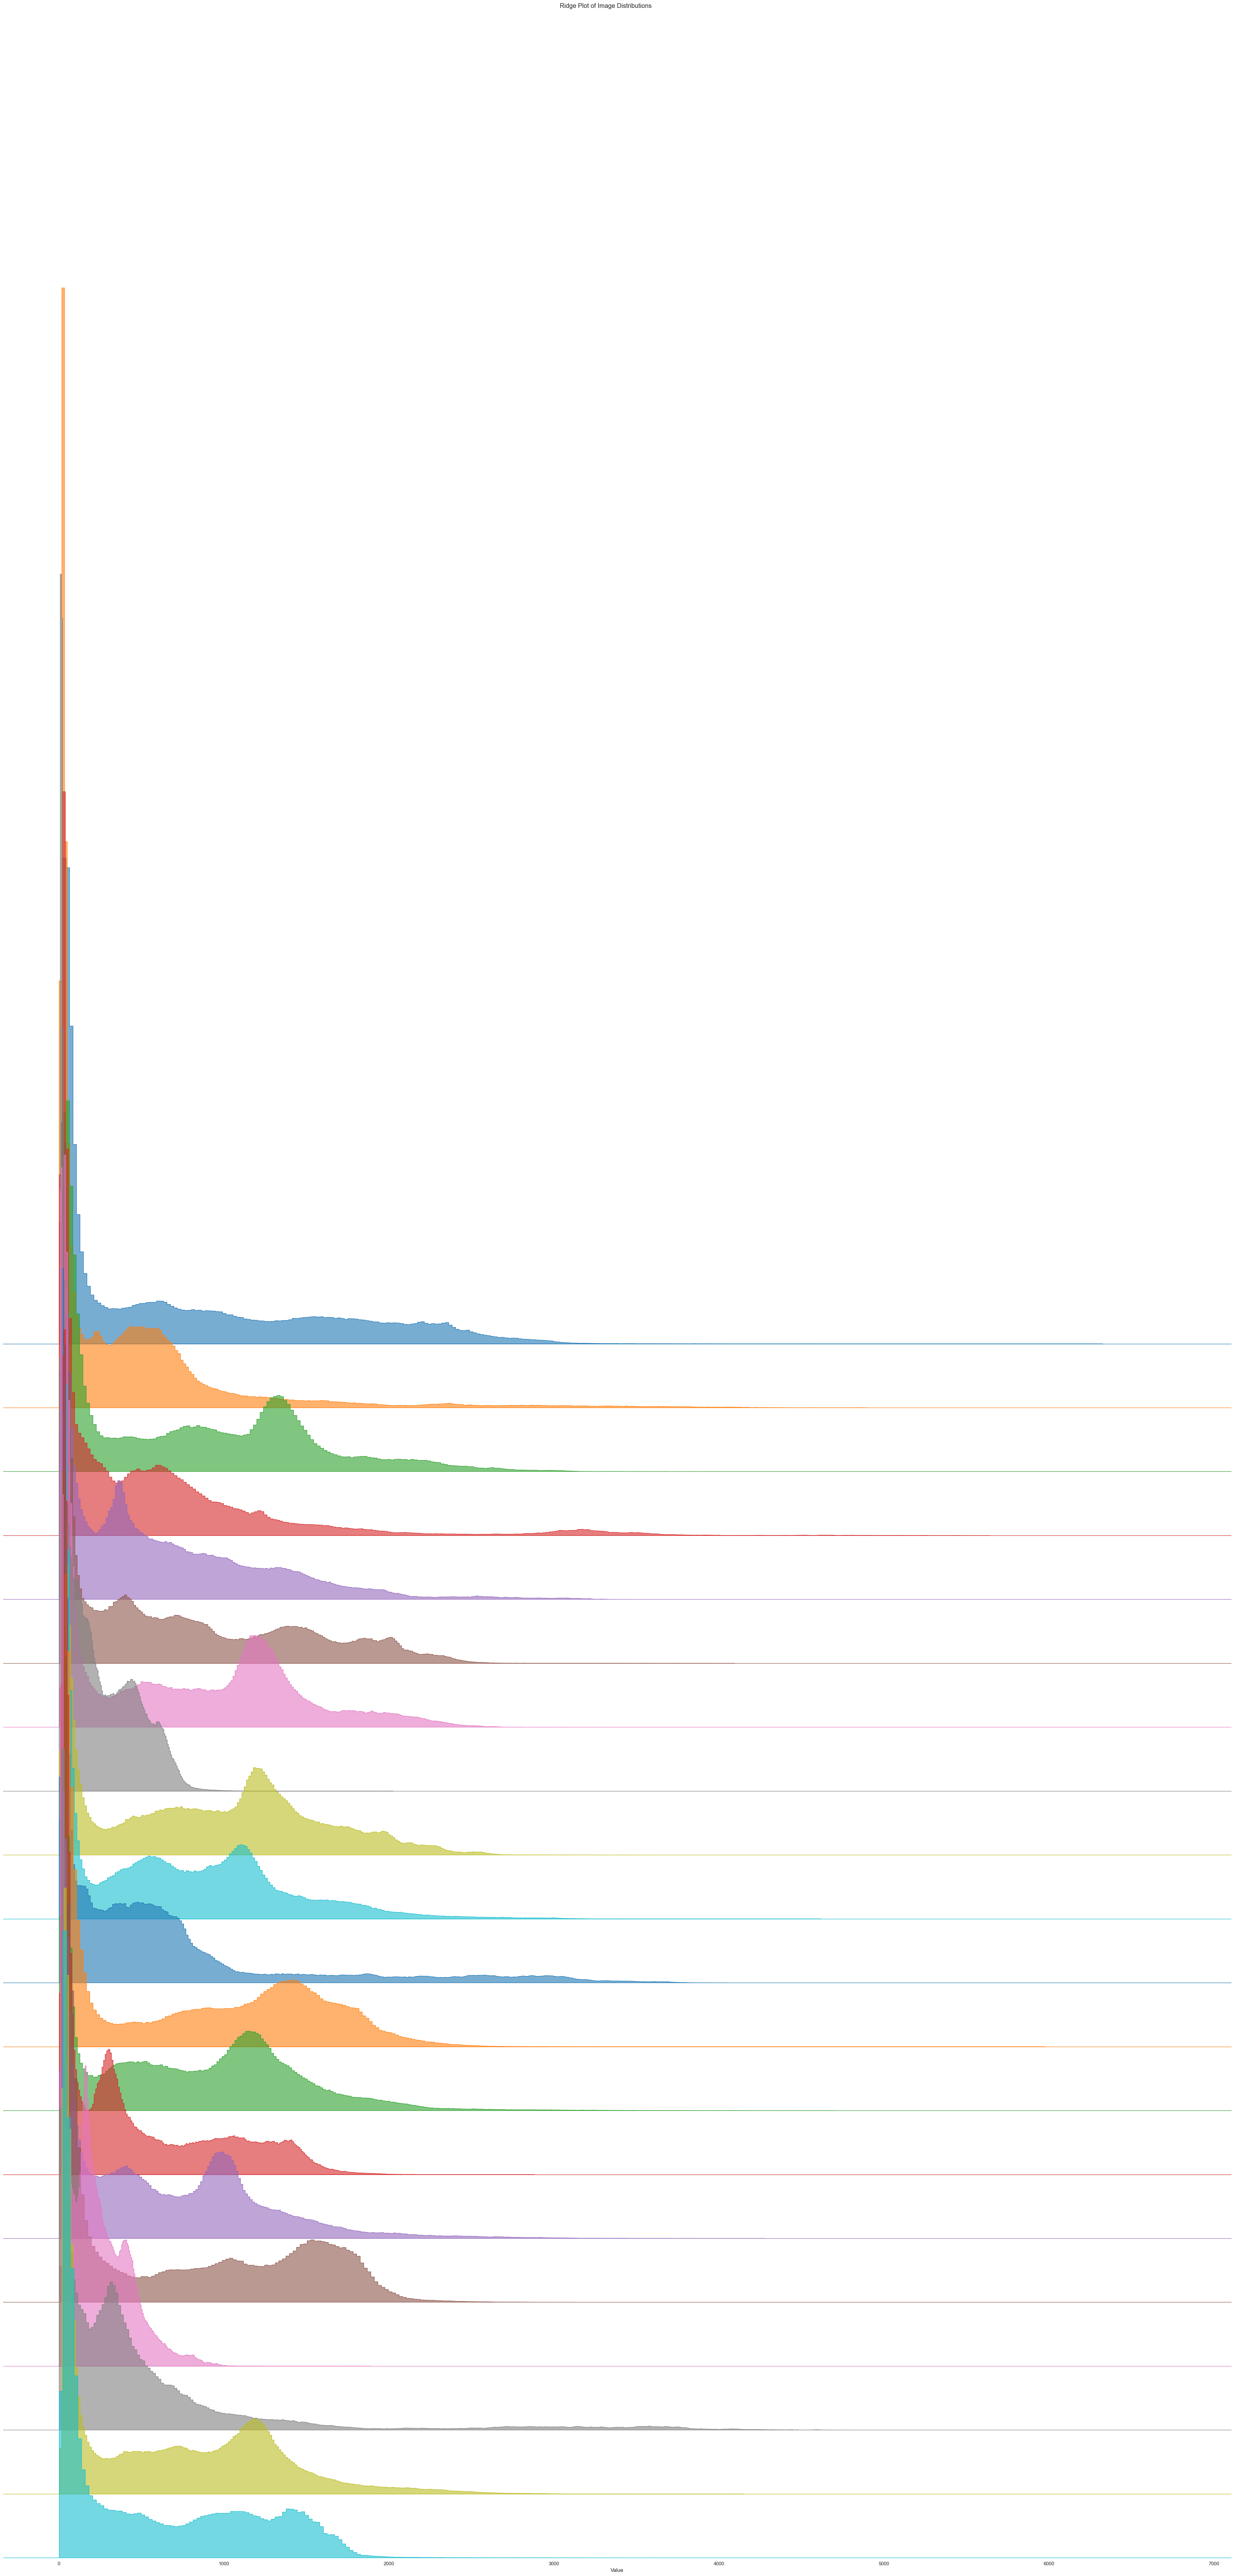

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
random_indices = np.random.randint(0, len(all_images), 20)
randomly_selected_images = [all_images[i] for i in random_indices]

records = []

df = pd.concat([
pd.DataFrame({
    "value": helpers.recursive_flatten(img),
    "dataset": f"Img {i}"
})
for i, img in enumerate(randomly_selected_images)
])
        

# Plot
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="dataset", hue="dataset", aspect=10, height=4, palette="tab10")

# Draw density curves
g.map(sns.histplot, "value", bins=300, stat="density", element="step", fill=True, alpha=0.6)


# Add baseline
g.map(plt.axhline, y=0, lw=1, clip_on=False)

# Overlap plots
g.figure.subplots_adjust(hspace=-0.95)

# Remove axes details
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.xlabel("Value")
plt.suptitle("Ridge Plot of Image Distributions", y=1.02)

plt.show()

(217025575, 1)


Text(0.5, 1.02, 'Ridge Plot of Image Distributions')

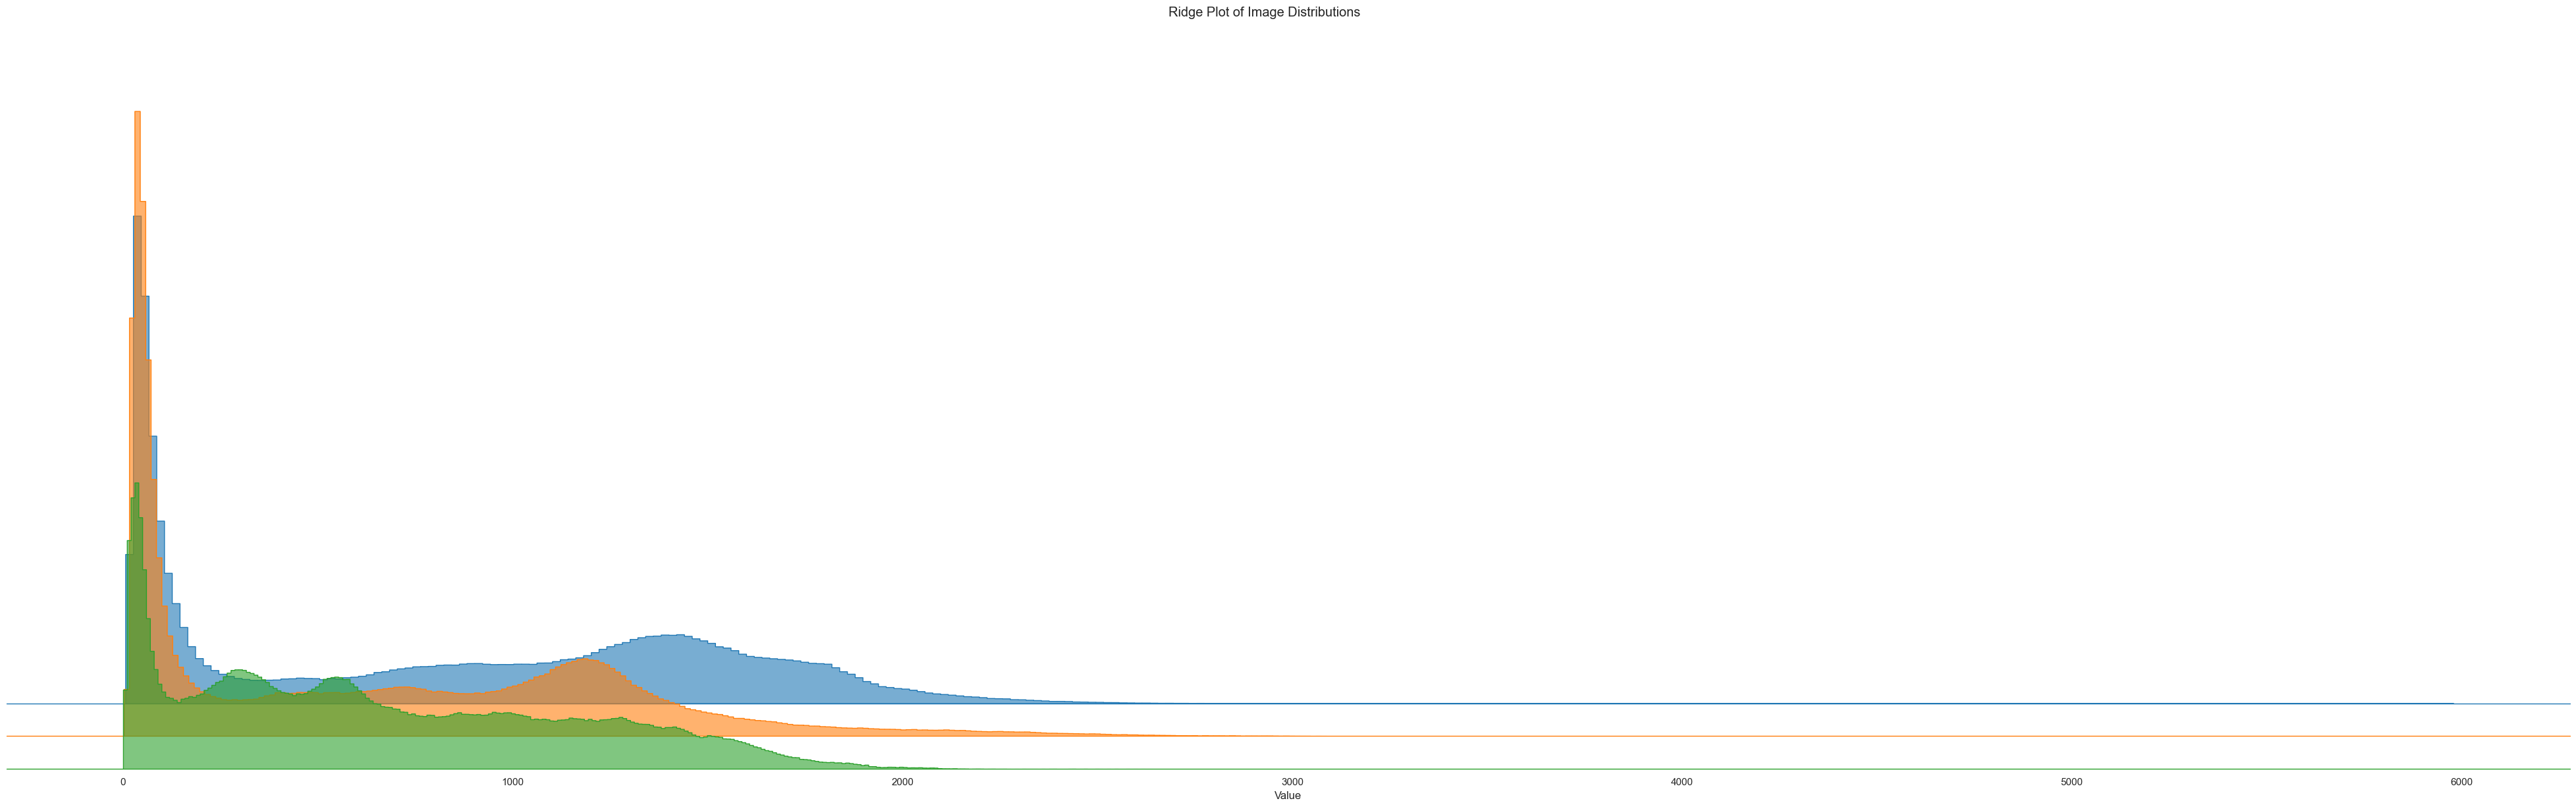

In [6]:
################################### MIN MAX SCALER ##########################################
from sklearn.preprocessing import MinMaxScaler

MinMax_scaler = MinMaxScaler()

all_pixels = np.array(helpers.recursive_flatten(all_images)).reshape(-1, 1)
print(all_pixels.shape)
MinMax_scaler = MinMax_scaler.fit(all_pixels)
################################################################################################

def clip_and_scale(img, clip=True, scaler=None):
    new_img = img.copy()
    if clip: new_img, _ = clip_outliers_from_img(img)
    if scaler: 
        orig_shape = new_img.shape
        new_img = scaler.transform(new_img.reshape(-1, 1)).reshape(orig_shape)
    return new_img



minmax_scaled_images = [clip_and_scale(img, clip=False, scaler=MinMax_scaler) for img in randomly_selected_images]

records = []

df = pd.concat([
pd.DataFrame({
    "value": helpers.recursive_flatten(img),
    "dataset": f"Img {i}"
})
for i, img in enumerate(randomly_selected_images)
])
        

# Plot
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="dataset", hue="dataset", aspect=10, height=4, palette="tab10")

# Draw density curves
g.map(sns.histplot, "value", bins=300, stat="density", element="step", fill=True, alpha=0.6)


# Add baseline
g.map(plt.axhline, y=0, lw=1, clip_on=False)

# Overlap plots
g.figure.subplots_adjust(hspace=-0.95)

# Remove axes details
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.xlabel("Value")
plt.suptitle("Ridge Plot of Image Distributions", y=1.02)

In [ ]:
# Visualizing an image before and after clipping


random_img = all_images[random.randint(0, len(all_images))]
clipped_image = helpers.clip_outliers_from_img(random_img)


figure,axis = plt.subplots(1,2,figsize=(10,10))
axis[0].imshow(random_img[:,:,1])
axis[0].set_title("IMAGE")
axis[1].imshow(clipped_image[:,:,1])
axis[1].set_title("Image after 99 percentile clipping")

IndexError: list index out of range